# 02 — Exploratory Data Analysis

**Dataset:** Global Coral Bleaching Database 1980–2020 (van Woesik & Kratochwill 2022)  
**Target variable:** `Percent_Bleaching`

---

## Contents

1. Missing values & data preparation
2. Target variable distribution
3. Temporal trends
4. Spatial patterns
5. Feature correlations with bleaching

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Setting pandas to show all columns: the dataset has 62 columns and pandas truncates by default
pd.set_option('display.max_columns', None)

In [2]:
# Project colour palette: ocean themed 🌊
color_primary = 'teal'
color_secondary = 'coral'  
color_accent = 'turquoise'

In [3]:
# Importing the cleaned data
df = pd.read_csv('../data/processed/bleaching_clean.csv', low_memory=False)
print(df.shape)
df.head()

(41361, 62)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,State_Island_Province_Name,City_Town_Name,Site_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Date_Day,Date_Month,Date_Year,Depth_m,Substrate_Name,Percent_Cover,Bleaching_Level,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,Havana,Havana,Puntilla,8519.23,Exposed,0.0287,49.90,15,9,2005,10.00,NaN,NaN,NaN,50.2,301.61,302.05,300.67,296.72,304.69,1.60,8.0,-0.46,1.0,0.0,-3.56,2.24,0.0,3.13,17.00,3.0,0.00,1.63,7.88,0.98,-0.80,1.60,-6.12,1.83,-2.17,0.00,1.09,5.0,0.0,0.00,0.74,7.25,0.18,2005-09-15,NaN,NaN,NaN
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,Society Islands,Moorea,NaN,1431.62,Exposed,0.0262,51.20,15,3,1991,14.00,NaN,NaN,NaN,50.7,262.15,303.30,300.73,297.58,305.01,1.12,2.0,1.29,1.0,0.0,-2.73,3.10,0.5,2.77,13.25,2.0,0.26,1.48,11.41,0.72,1.29,1.12,-4.42,3.00,-1.26,0.25,0.93,4.0,0.0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,NaN
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,British Virgin Islands,Peter Island,Coral Gardens,182.33,Exposed,0.0429,61.52,15,1,2006,7.00,NaN,NaN,NaN,50.9,298.79,299.18,300.32,297.12,304.14,1.22,8.0,0.04,1.0,0.0,-2.92,2.83,16.0,4.52,23.00,3.0,0.00,2.45,16.24,1.26,-2.64,1.22,-4.69,2.31,-1.49,7.00,1.31,7.0,0.0,0.00,1.04,11.66,0.26,2006-01-15,NaN,NaN,NaN
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3219,313.13,Exposed,0.0424,65.39,15,4,2006,9.02,NaN,NaN,NaN,50.9,300.16,299.61,300.38,297.25,304.07,1.19,3.0,-0.07,1.0,0.0,-2.77,2.47,22.0,4.75,24.00,3.0,0.00,2.37,16.73,1.07,-2.27,1.19,-4.63,2.19,-1.49,3.00,0.94,4.0,0.0,0.00,0.75,5.64,0.20,2006-04-15,NaN,NaN,NaN
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3194,792.00,Exposed,0.0424,65.39,15,4,2006,12.50,NaN,NaN,NaN,50.9,300.15,299.70,300.38,296.63,303.76,1.18,3.0,0.00,1.0,0.0,-2.84,2.30,16.0,4.16,20.00,3.0,0.00,2.24,13.86,1.16,-2.19,1.18,-5.25,1.87,-1.50,3.00,1.33,5.0,0.0,0.00,0.92,6.89,0.25,2006-04-15,NaN,NaN,NaN


## 1. Missing Values & Data Preparation

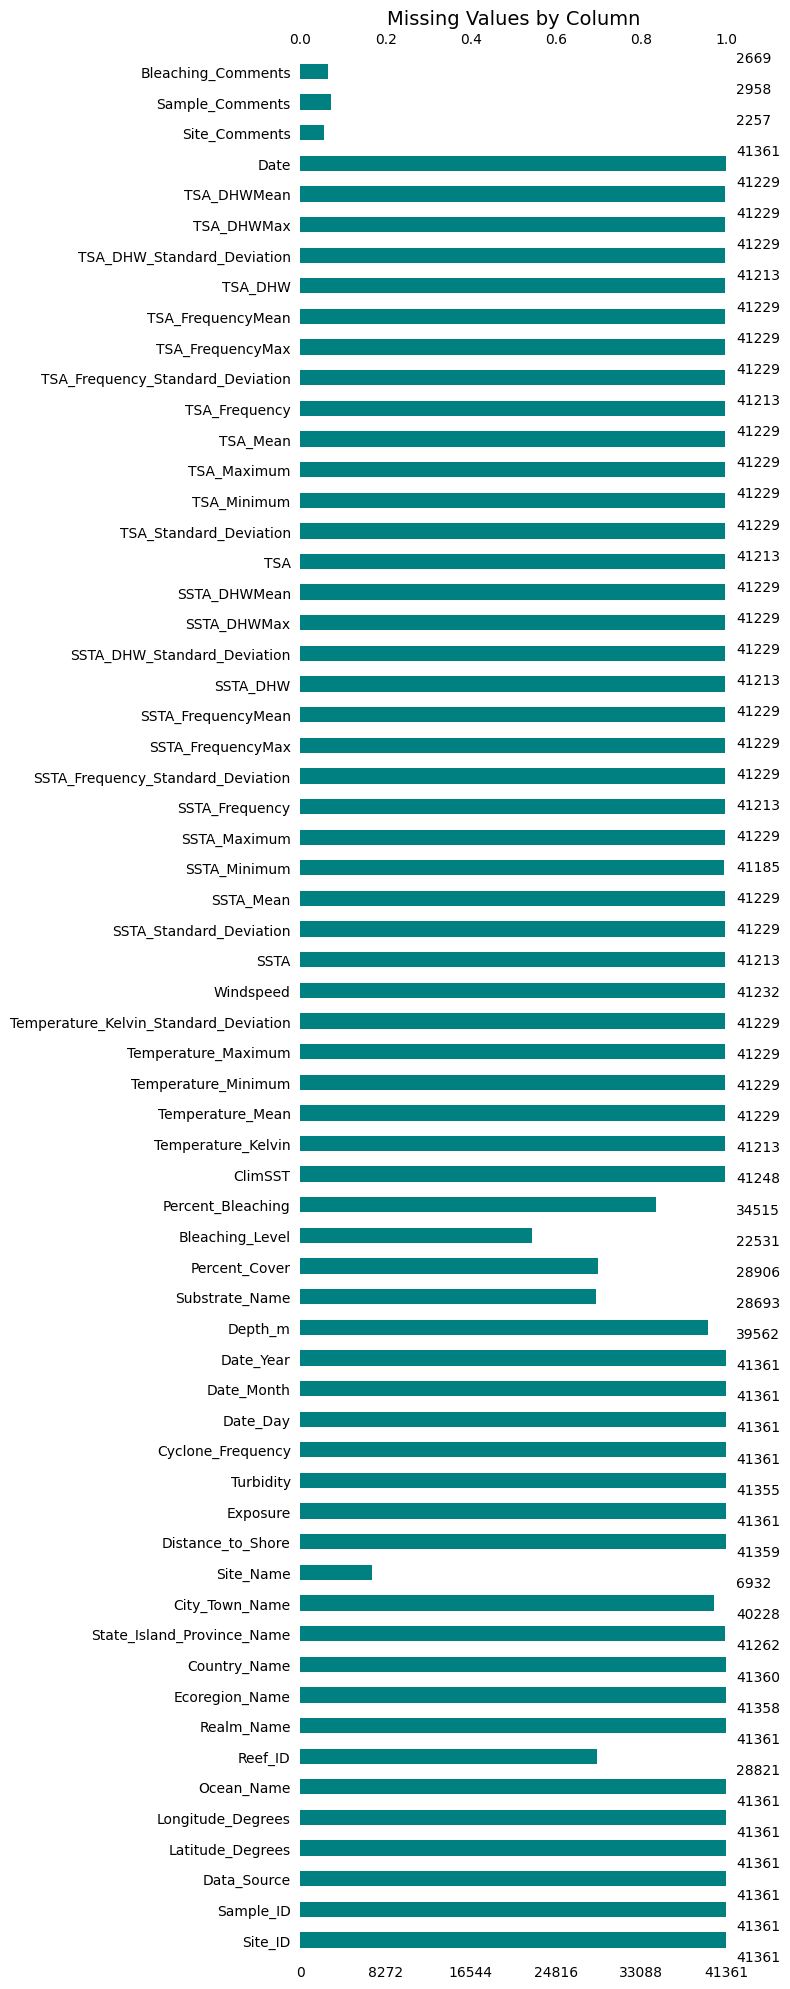

In [4]:
# Overview of missing values across all columns
fig, ax = plt.subplots(figsize=(8, 20))
msno.bar(df, ax=ax, color=color_primary, fontsize=10)
plt.title('Missing Values by Column', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/missing_values_bar.png', bbox_inches='tight')
plt.show()

### Missing Values Matrix
The matrix is most useful for smaller datasets or when inspecting specific column subsets.
With 62 columns the bar chart above is more informative at this scale.

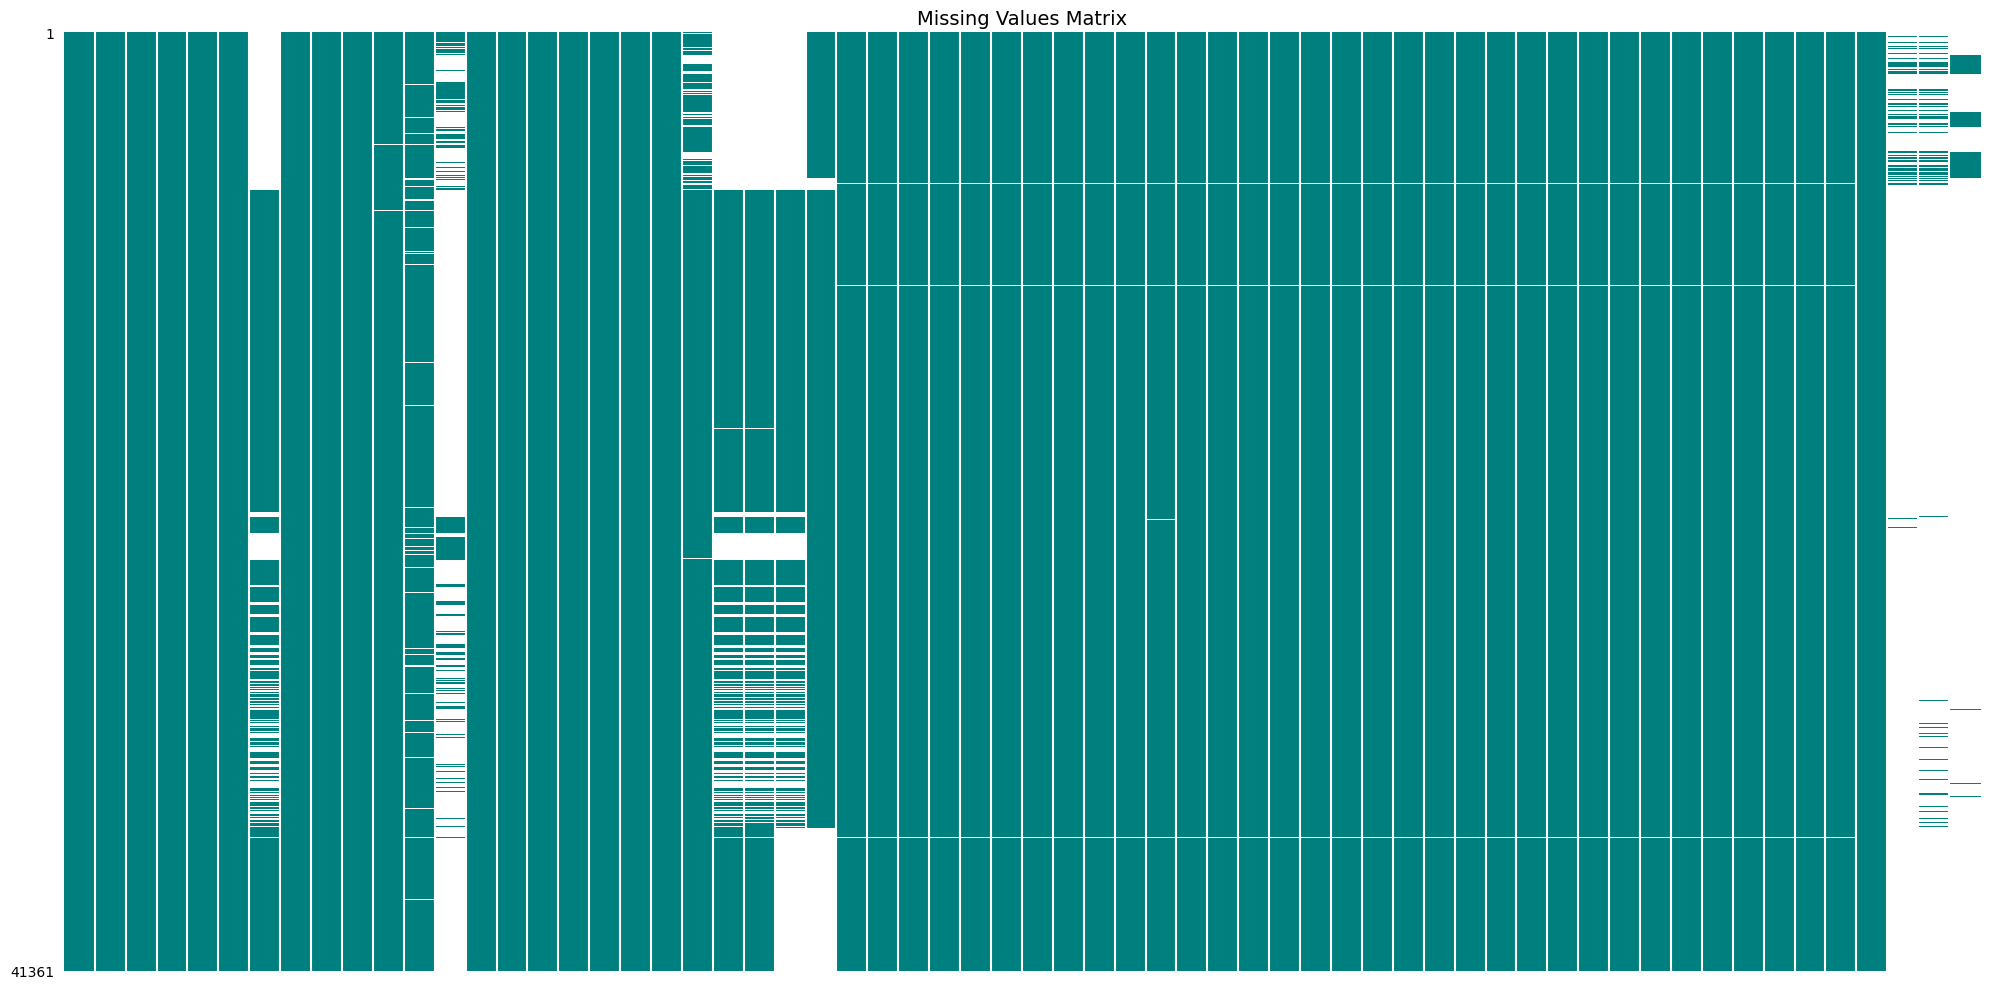

In [5]:
# Pattern of missing values
fig, ax = plt.subplots(figsize=(20, 10))
msno.matrix(df, ax=ax, color=(0, 0.5, 0.5), fontsize=8, sparkline=False)
plt.title('Missing Values Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/missing_values_matrix.png', bbox_inches='tight')
plt.show()

In [6]:
# Check comments for algae and seaweed observations
algae_mask = df['Substrate_Name'].isin(['Nutrient Indicator Algae', 'Fleshy Seaweed'])
df[algae_mask][['Substrate_Name', 'Site_Comments', 'Sample_Comments', 'Bleaching_Comments']]

,Substrate_Name,Site_Comments,Sample_Comments,Bleaching_Comments
6982,Nutrient Indicator Algae,NaN,NaN,NaN
6984,Nutrient Indicator Algae,NaN,NaN,NaN
6986,Nutrient Indicator Algae,NaN,NaN,NaN
6988,Nutrient Indicator Algae,NaN,NaN,NaN
6990,Nutrient Indicator Algae,NaN,NaN,NaN
...,...,...,...,...
41339,Fleshy Seaweed,NaN,NaN,NaN
41341,Fleshy Seaweed,NaN,NaN,NaN
41356,Nutrient Indicator Algae,NaN,NaN,NaN
41358,Nutrient Indicator Algae,NaN,NaN,NaN


In [7]:
df.groupby('Data_Source')['Substrate_Name'].apply(lambda x: x.isna().sum() / len(x) * 100).sort_values(ascending=False)

Data_Source
AGRRA         100.000000
Donner        100.000000
FRRP          100.000000
Kumagai       100.000000
McClanahan    100.000000
Nuryana       100.000000
Safaie        100.000000
Setiawan      100.000000
Reef_Check      0.444121
Name: Substrate_Name, dtype: float64

In [8]:
df[df['Data_Source'] == 'Reef_Check']['Substrate_Name'].value_counts(dropna=False)

Substrate_Name
Hard Coral                  14347
Nutrient Indicator Algae    11967
Fleshy Seaweed               2379
NaN                           128
Name: count, dtype: int64

In [9]:
df['Data_Source'].value_counts()

Data_Source
Reef_Check    28821
Donner         6307
AGRRA          2848
FRRP           2394
Kumagai         667
McClanahan      234
Safaie           81
Nuryana           5
Setiawan          4
Name: count, dtype: int64

### Substrate_Name: source and ecological interpretation

'Substrate_Name' is populated exclusively by Reef Check observations (99.6% non-null for Reef Check vs 100% null for all other sources). This reflects Reef Check's broader monitoring protocol, which records substrate composition in addition to bleaching percentage and animal species population.

The three substrate categories carry distinct ecological meaning:
- **Hard Coral**: healthy, bleached or recovering reef structure
- **Nutrient Indicator Algae** and **Fleshy Seaweed**: algae-dominated substrate, typically indicative of reef degradation

Algae dominance is often a post-bleaching successional state: when coral dies, algae colonises the freed substrate. Retaining these categories as a categorical feature rather than dropping them preserves this ecological signal.

NaN values (non-Reef Check sources) will be kept as a separate category, as missingness here is structurally informative: it encodes source identity.

In [10]:
# Column drops informed by the missing value analysis above — done here rather than in notebook 01
# Dropping columns with excessive missing values that add no predictive value:
# - Site_Comments, Sample_Comments, Bleaching_Comments: ~95% NaN, free text, not useful for modelling
# - Site_Name: ~83% NaN, location already captured by Latitude_Degrees and Longitude_Degrees

df = df.drop(columns=['Site_Comments', 'Sample_Comments', 'Bleaching_Comments', 'Site_Name'])

print(df.shape)

(41361, 58)


In [11]:
# Inspect Bleaching_Level before dropping: could be a categorical version of the target
print(df['Bleaching_Level'].value_counts(dropna=False))

Bleaching_Level
Population    22531
NaN           18830
Name: count, dtype: int64


In [12]:
# Dropping Bleaching_Level: single non-null value ('Population'), metadata not predictive
df.drop(columns=['Bleaching_Level'], inplace=True)

print(df.shape)

(41361, 57)


## 2. Target Variable Distribution

In [13]:
# Basic statistics for Percent_Bleaching
# This tells us the shape of the distribution before any binarisation decision
print(df['Percent_Bleaching'].describe().T)

count    34515.000000
mean         9.619465
std         20.190956
min          0.000000
25%          0.000000
50%          0.250000
75%          6.000000
max        100.000000
Name: Percent_Bleaching, dtype: float64


### Target Variable: Percent_Bleaching

`Percent_Bleaching` is a continuous variable ranging from 0 to 100. The statistical summary reveals a heavily right-skewed, zero-inflated distribution:

- 25th percentile = 0%: at least a quarter of observations show no bleaching at all
- Median = 0.25%: half the dataset has less than 0.25% bleaching
- Mean = 9.6%: pulled upward by extreme events
- Standard deviation = 20%: large relative to the median, confirming a long right tail

For binary classification, we need to define a threshold above which an observation is labelled as "bleached". The choice of threshold has direct consequences on class balance and on the ecological meaning of what we are asking the model to learn.

We test three candidate thresholds to evaluate the resulting class balance and decide which best captures ecologically meaningful bleaching events.

In [14]:
total = df['Percent_Bleaching'].notna().sum()

for threshold in [0, 10, 20]:
    bleached = (df['Percent_Bleaching'] > threshold).sum()
    not_bleached = total - bleached
    print(f"> {threshold:2d}%  =>  bleached: {bleached:>6} ({bleached/total*100:.1f}%)  |  not bleached: {not_bleached:>6} ({not_bleached/total*100:.1f}%)")

>  0%  =>  bleached:  17886 (51.8%)  |  not bleached:  16629 (48.2%)
> 10%  =>  bleached:   6936 (20.1%)  |  not bleached:  27579 (79.9%)
> 20%  =>  bleached:   5240 (15.2%)  |  not bleached:  29275 (84.8%)


In [15]:
between = ((df['Percent_Bleaching'] > 0) & (df['Percent_Bleaching'] <= 10)).sum()
print(f"Observations between 0% and 10%: {between} ({between/total*100:.1f}%)")

Observations between 0% and 10%: 10950 (31.7%)


### Binarisation Threshold: 10%

Based on the distribution analysis, we create a binary target column using a 10% threshold:
- **0 (not bleached)**: Percent_Bleaching ≤ 10% - includes zero observations and low-level events considered ecological background noise
- **1 (bleached)**: Percent_Bleaching > 10% - captures ecologically significant bleaching events

Observations between 0% and 10% (31.7% of the dataset) are classified as not bleached: a reef with 2% bleaching is not in crisis.

Note: the original `Percent_Bleaching` column is retained for reference.

In [16]:
# Creating binary target column using 10% threshold
# Ecologically meaningful: events below 10% are considered background noise
df['Bleaching_Binary'] = (df['Percent_Bleaching'] > 10).astype(int)

print(df['Bleaching_Binary'].value_counts())
print(f"\nClass balance: {df['Bleaching_Binary'].mean()*100:.1f}% bleached")

Bleaching_Binary
0    34425
1     6936
Name: count, dtype: int64

Class balance: 16.8% bleached


## 3. Temporal Trends

Before plotting, we inspect the temporal coverage of the dataset: how many observations per year, and whether coverage is uniform across the 1980–2020 range.

In [17]:
print(df['Date_Year'].min(), df['Date_Year'].max())
print(df['Date_Year'].value_counts().sort_index())

1980 2020
Date_Year
1980       2
1983      25
1984       1
1985       1
1986       6
1987      51
1988       6
1989       1
1990       4
1991       9
1992       8
1993      11
1994      23
1995      15
1996      28
1997     784
1998    1432
1999    1232
2000    1189
2001    1715
2002    2098
2003    2030
2004    1936
2005    4179
2006    2914
2007    1769
2008    2046
2009    2246
2010    1871
2011    1408
2012    1490
2013    1650
2014    1527
2015    1661
2016    1855
2017    1607
2018    1245
2019    1196
2020      90
Name: count, dtype: int64


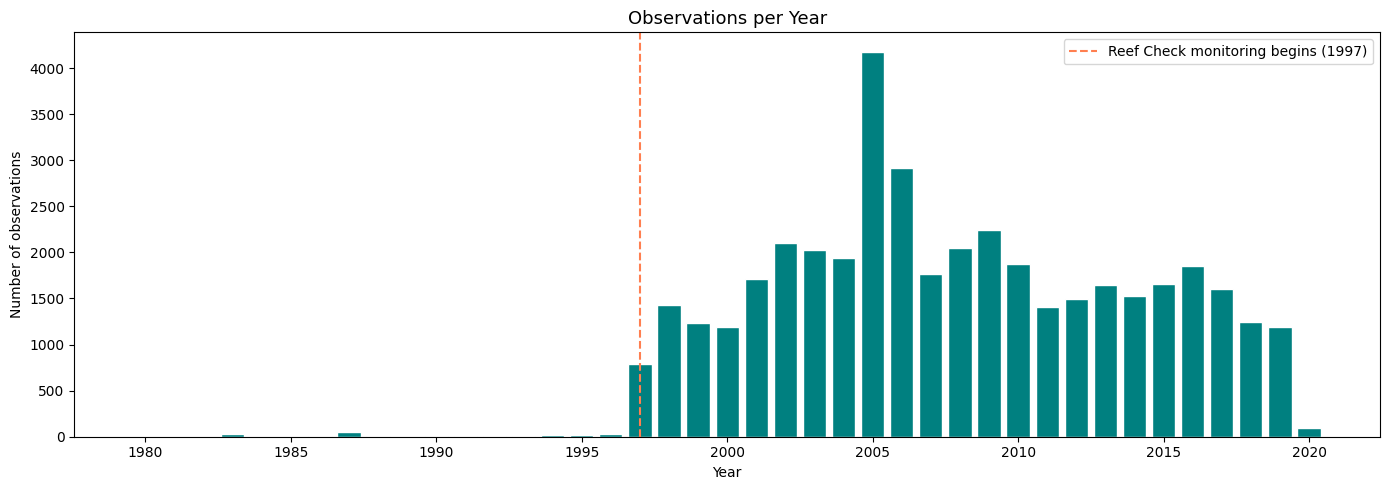

In [18]:
# Observations per year: checking temporal coverage before plotting trends
obs_per_year = df['Date_Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(obs_per_year.index, obs_per_year.values, color=color_primary, edgecolor='white')
ax.set_title('Observations per Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of observations')
ax.axvline(x=1997, color=color_secondary, linestyle='--', linewidth=1.5, label='Reef Check monitoring begins (1997)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/observations_per_year.png', bbox_inches='tight')
plt.show()

In [ ]:
# Checking the total amount of data pre-1997
print(df[df['Date_Year'] < 1997]['Data_Source'].value_counts())
print(f"\nTotal rows pre-1997: {(df['Date_Year'] < 1997).sum()}")

Data_Source
Donner    191
Name: count, dtype: int64

Total rows pre-1997: 191


In [20]:
# Checking if those 191 raws present data of bleaching
print(df[df['Date_Year'] < 1997]['Bleaching_Binary'].value_counts())

Bleaching_Binary
0    107
1     84
Name: count, dtype: int64


In [21]:
# Checking the sites that were monitored to see whether they have been monitored also after 1997
# Check geographic distribution of pre-1997 observations
print(df[df['Date_Year'] < 1997][['Latitude_Degrees', 'Longitude_Degrees', 'Country_Name', 'Date_Year']].sort_values('Date_Year'))

      Latitude_Degrees  Longitude_Degrees          Country_Name  Date_Year
1402          -27.1667          -109.3333                 Chile       1980
3748          -27.1000          -109.3000                 Chile       1980
1415            5.5500           -87.0600            Costa Rica       1983
919             9.5500           -78.8667                Panama       1983
1427           -0.8167           -89.5333               Ecuador       1983
...                ...                ...                   ...        ...
2679          -17.5750          -149.7833      French Polynesia       1996
1745           -2.6833           150.5667      Papua New Guinea       1996
1822           24.4500            54.3833  United Arab Emirates       1996
877           -10.0370           150.8340      Papua New Guinea       1996
6929           21.4100          -157.7380         United States       1996

[191 rows x 4 columns]


In [22]:
# Check if pre-1997 sites appear in post-1997 data
# Using rounded coordinates to account for slight positional differences
pre97 = df[df['Date_Year'] < 1997][['Latitude_Degrees', 'Longitude_Degrees']].round(1)

post97 = df[df['Date_Year'] >= 1997][['Latitude_Degrees', 'Longitude_Degrees']].round(1)

# Find matches
pre97_tuples = set(zip(pre97['Latitude_Degrees'], pre97['Longitude_Degrees']))
post97_tuples = set(zip(post97['Latitude_Degrees'], post97['Longitude_Degrees']))

overlap = pre97_tuples.intersection(post97_tuples)
print(f"Pre-1997 unique sites: {len(pre97_tuples)}")
print(f"Sites also monitored post-1997: {len(overlap)}")

Pre-1997 unique sites: 136
Sites also monitored post-1997: 80


Although pre-1997 observations are sparse (n=191, <0.5% of the dataset), their presence may reflect early documentation of bleaching stress before systematic monitoring began. 80 out of 136 pre-1997 sites (59%) were monitored again post-1997, confirming geographic continuity. All rows are retained in the dataset.

## Temporal bleaching trends across the dataset
Checking the bleaching events across the dataset in terms of temporal analysis: when were the major bleaching events registered?

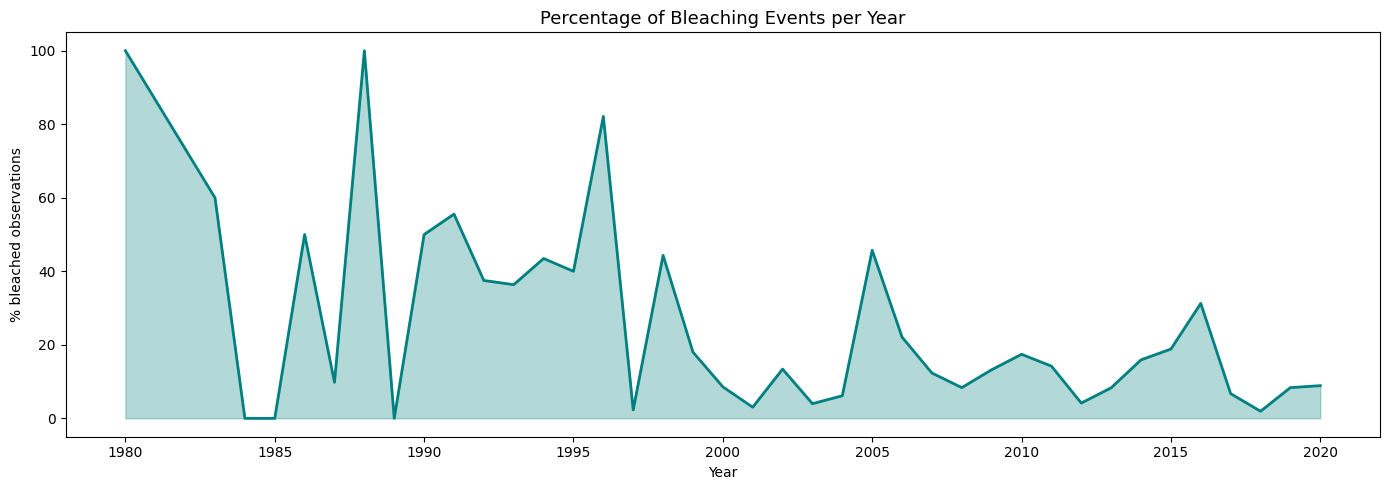

In [23]:
# Percentage of bleached observations per year (Bleaching_Binary mean = proportion of bleached events)
bleaching_by_year = df.groupby('Date_Year')['Bleaching_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bleaching_by_year.index, bleaching_by_year.values, color=color_primary, linewidth=2)
ax.fill_between(bleaching_by_year.index, bleaching_by_year.values, alpha=0.3, color=color_primary)
ax.set_title('Percentage of Bleaching Events per Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('% bleached observations')
plt.tight_layout()
plt.savefig('../outputs/figures/bleaching_trend_by_year.png', bbox_inches='tight')
plt.show()

The percentage alone can be misleading because it does not relate the bleaching events to the number of observations per year. Years with few observations but high bleaching percentage would show an inflated proportion of bleaching events, introducing bias. The two panels below should therefore be read together.

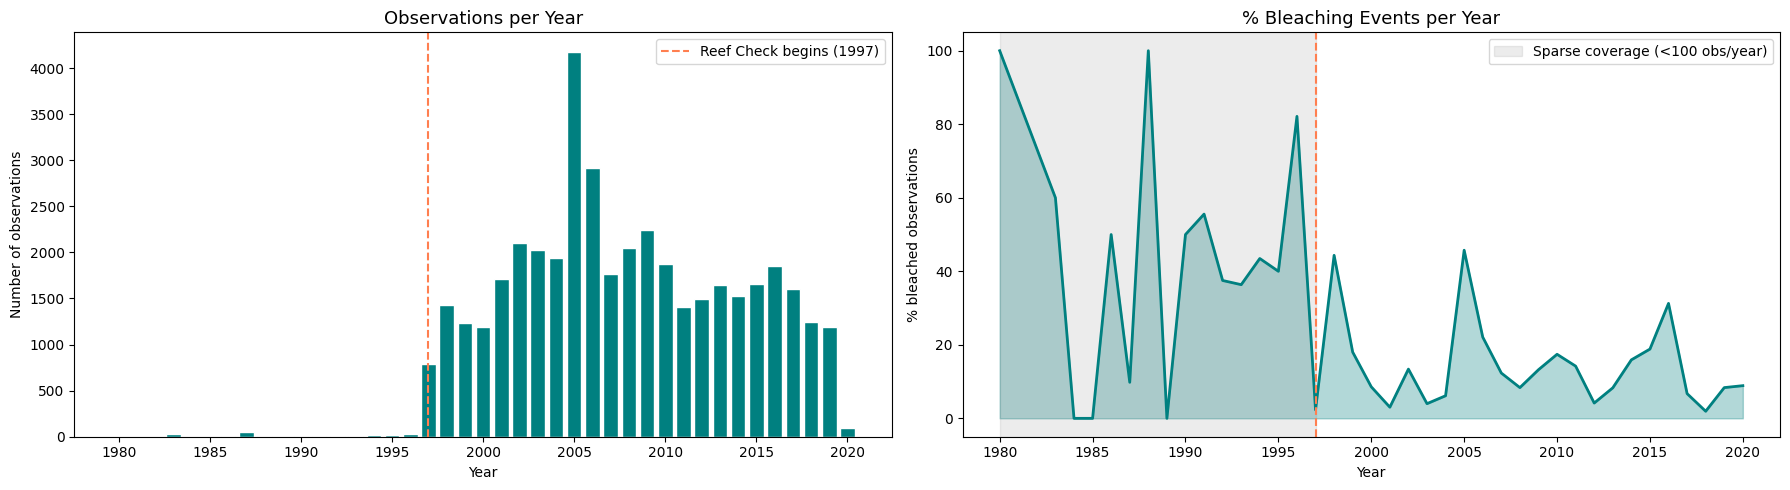

In [25]:
# Combining temporal coverage and bleaching trend in a single figure
# Left: observation count per year (context for interpreting the right panel)
# Right: % bleached per year — unreliable where observation count is low

bleaching_by_year = df.groupby('Date_Year')['Bleaching_Binary'].mean() * 100
obs_per_year = df['Date_Year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: observations per year
axes[0].bar(obs_per_year.index, obs_per_year.values, color=color_primary, edgecolor='white')
axes[0].axvline(x=1997, color=color_secondary, linestyle='--', linewidth=1.5, label='Reef Check begins (1997)')
axes[0].set_title('Observations per Year', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of observations')
axes[0].legend()

# Right: % bleached per year, greyed out pre-1997
axes[1].plot(bleaching_by_year.index, bleaching_by_year.values, color=color_primary, linewidth=2)
axes[1].fill_between(bleaching_by_year.index, bleaching_by_year.values, alpha=0.3, color=color_primary)
axes[1].axvspan(1980, 1997, alpha=0.15, color='grey', label='Sparse coverage (<100 obs/year)')
axes[1].axvline(x=1997, color=color_secondary, linestyle='--', linewidth=1.5)
axes[1].set_title('% Bleaching Events per Year', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% bleached observations')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/temporal_trends_combined.png', bbox_inches='tight')
plt.show()

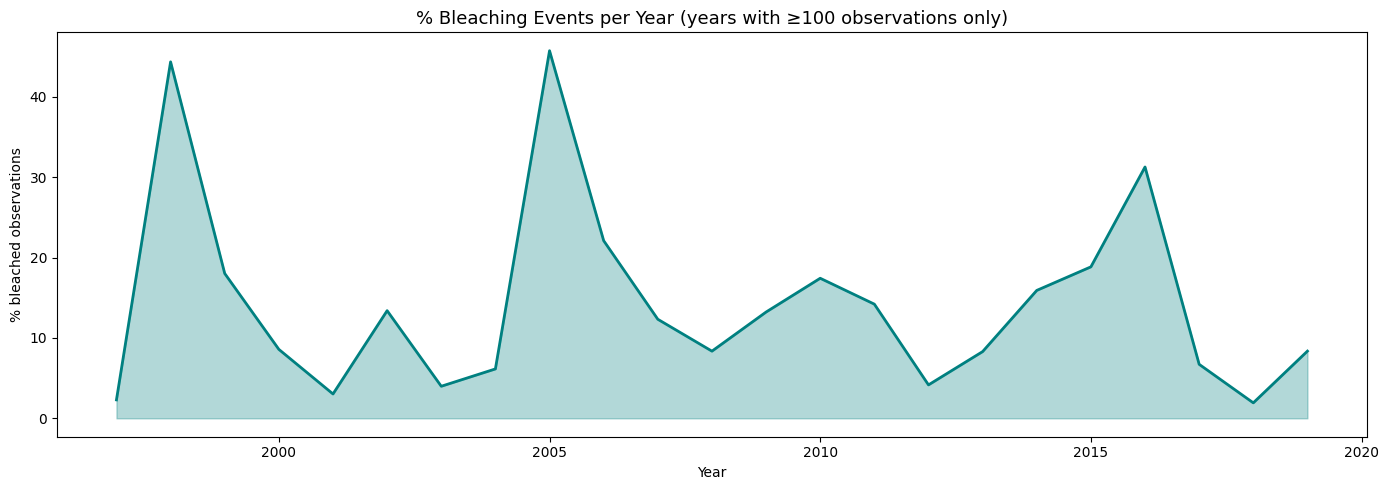

In [26]:
# Filtering years with at least 100 observations to reduce noise from sparse coverage
min_obs = 100
years_reliable = obs_per_year[obs_per_year >= min_obs].index

bleaching_reliable = bleaching_by_year[bleaching_by_year.index.isin(years_reliable)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bleaching_reliable.index, bleaching_reliable.values, color=color_primary, linewidth=2)
ax.fill_between(bleaching_reliable.index, bleaching_reliable.values, alpha=0.3, color=color_primary)
ax.set_title('% Bleaching Events per Year (years with ≥100 observations only)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('% bleached observations')
plt.tight_layout()
plt.savefig('../outputs/figures/bleaching_trend_reliable_years.png', bbox_inches='tight')
plt.show()

The peaks in the post-1997 graph coincide with three major bleaching events documented in the literature:

- **1997/98**: El Niño triggered the most severe global bleaching event ever recorded at the time
- **2005**: massive bleaching event in the Caribbean, documented by NOAA as the worst on record for the Atlantic region
- **2016**: third global mass bleaching event, during which the Great Barrier Reef suffered its most severe bleaching to date

The dataset's ability to capture all three events is an indirect validation of its quality and temporal coverage.